# Semana 7 - Visualização de Dados

1. Escolha um dataset;
2. Crie pelo menos:
    * Um histograma;
    * Um scaterplot;
    * Um boxplot;
3. Escreva 2-3 frases interpretando cada gráfico;


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("guavocado/pokemon-stats-1025-pokemons")

print("Path to dataset files:", path)

100%|██████████| 43.8k/43.8k [00:00<00:00, 28.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/guavocado/pokemon-stats-1025-pokemons/versions/1


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_pkm = pd.read_csv(path + "/pokemon_data.csv")
df_pkm.info()
df_pkm.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dexnum           1025 non-null   int64  
 1   name             1025 non-null   object 
 2   generation       1025 non-null   int64  
 3   type1            1025 non-null   object 
 4   type2            526 non-null    object 
 5   species          1025 non-null   object 
 6   height           1025 non-null   float64
 7   weight           1025 non-null   float64
 8   ability1         1025 non-null   object 
 9   ability2         858 non-null    object 
 10  hidden_ability   530 non-null    object 
 11  hp               1025 non-null   int64  
 12  attack           1025 non-null   int64  
 13  defense          1025 non-null   int64  
 14  sp_atk           1025 non-null   int64  
 15  sp_def           1025 non-null   int64  
 16  speed            1025 non-null   int64  
 17  total         

,dexnum,name,generation,type1,type2,species,height,weight,ability1,ability2,...,catch_rate,base_friendship,base_exp,growth_rate,egg_group1,egg_group2,percent_male,percent_female,egg_cycles,special_group
0,1,Bulbasaur,1,Grass,Poison,Seed Pokémon,0.7,6.9,Overgrow,Chlorophyll,...,45,50,64,Medium Slow,Grass,Monster,87.5,12.5,20,Ordinary
1,2,Ivysaur,1,Grass,Poison,Seed Pokémon,1.0,13.0,Overgrow,Chlorophyll,...,45,50,142,Medium Slow,Grass,Monster,87.5,12.5,20,Ordinary
2,3,Venusaur,1,Grass,Poison,Seed Pokémon,2.0,100.0,Overgrow,Chlorophyll,...,45,50,236,Medium Slow,Grass,Monster,87.5,12.5,20,Ordinary
3,4,Charmander,1,Fire,NaN,Lizard Pokémon,0.6,8.5,Blaze,Solar Power,...,45,50,62,Medium Slow,Dragon,Monster,87.5,12.5,20,Ordinary
4,5,Charmeleon,1,Fire,NaN,Flame Pokémon,1.1,19.0,Blaze,Solar Power,...,45,50,142,Medium Slow,Dragon,Monster,87.5,12.5,20,Ordinary


/tmp/ipykernel_6882/4216892552.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coluna', y='Quantidade', data=contagens, palette='Set1')


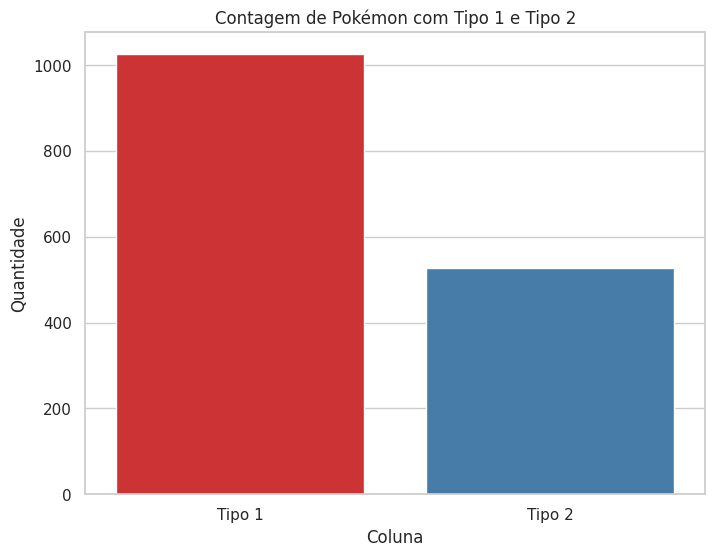

In [26]:
contagens = pd.DataFrame({
    'Coluna': ['Tipo 1', 'Tipo 2'],
    'Quantidade': [df_pkm['type1'].count(), df_pkm['type2'].count()]
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Coluna', y='Quantidade', data=contagens, palette='Set1')
plt.title('Contagem de Pokémon com Tipo 1 e Tipo 2')
plt.ylabel('Quantidade')
plt.show()

### Interpretação: Contagem de Tipos
Este gráfico de barras compara quantos Pokémon possuem o tipo primário (Tipo 1) e quantos possuem um tipo secundário (Tipo 2). Observamos que todos os 1025 Pokémon têm um tipo principal, mas apenas cerca de metade deles possui uma combinação de dois tipos.

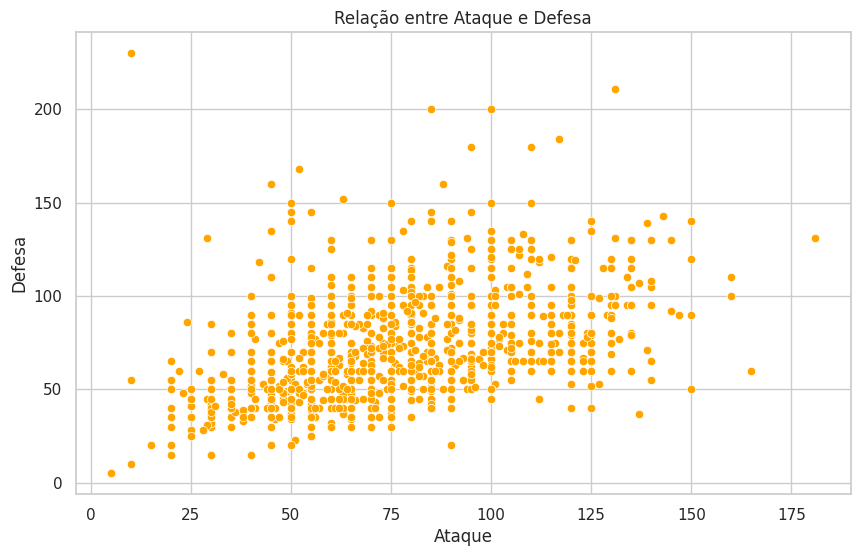

In [19]:
# 2. Scatterplot: Ataque vs Defesa
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pkm, x='attack', y='defense', color='orange')
plt.title('Relação entre Ataque e Defesa')
plt.xlabel('Ataque')
plt.ylabel('Defesa')
plt.show()

### Interpretação: Scatterplot de Ataque vs Defesa
Este gráfico de dispersão analisa se existe uma correlação entre o poder de ataque e a defesa dos Pokémon. A dispersão dos pontos sugere que, embora haja uma tendência geral de crescimento mútuo, existem muitos Pokémon especializados em apenas um dos atributos (ataque muito alto com defesa baixa, ou vice-versa).

/tmp/ipykernel_6882/1618579910.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pkm, x='generation', y='speed', palette='Set3')


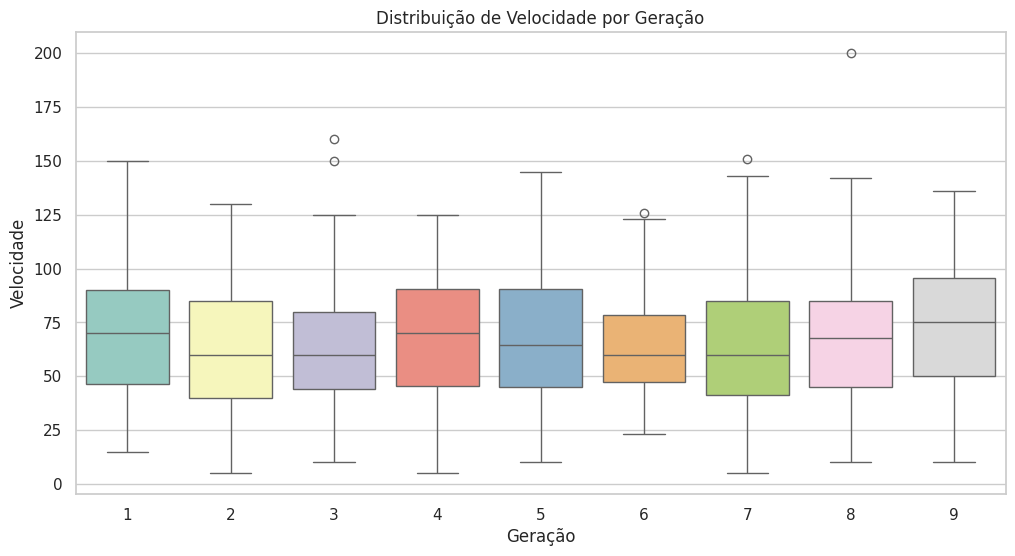

In [20]:
# 3. Boxplot: Velocidade por Geração
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_pkm, x='generation', y='speed', palette='Set3')
plt.title('Distribuição de Velocidade por Geração')
plt.xlabel('Geração')
plt.ylabel('Velocidade')
plt.show()

### Interpretação: Boxplot de Velocidade por Geração
O boxplot permite comparar a mediana e a variação da velocidade dos Pokémon ao longo das gerações. Notamos que a velocidade média permanece relativamente constante entre as gerações, embora algumas possuam mais 'outliers' (Pokémon extremamente rápidos ou lentos) do que outras.